In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from ranking import (load_all, compute_scores, print_ranking_table,
                     extract_ranked_arrays, pareto_front)

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# --- Load everything once ---
data = load_all(
    particle_file=Path("../data/tng_particles/particles_099.hdf5"),
    results_dir=Path("../results"),
    result_pattern="fit_ext_maths_DM_compl{comp}_particles_099.hdf5",
    complexities=[4, 5, 6, 7],
)

Loaded 904 halos from particles_099.hdf5
  M200c range: 1.00e+12 - 6.70e+13 Msun/h
  compl4: 30736 results, 34 functions
  compl5: 232369 results, 262 functions
  compl6: 1732442 results, 1973 functions
  compl7: 13634754 results, 15721 functions


In [12]:
# --- Mass filter & scoring (re-run this cell to change cuts) ---
min_mass = None   # e.g. 1e13 [Msun/h], None = no cut
max_mass = None    # e.g. 1e14 [Msun/h], None = no cut
max_params = 3 # e.g. 3 to keep only functions with k <= 3, None = no cut
n_top = 30

halo_mask = np.ones(data["n_halos"], dtype=bool)
if min_mass is not None:
    halo_mask &= data["M200c"] >= min_mass
if max_mass is not None:
    halo_mask &= data["M200c"] <= max_mass

print(f"Halos selected: {halo_mask.sum()}/{data['n_halos']}")
if min_mass is not None or max_mass is not None:
    sel = data["M200c"][halo_mask]
    print(f"  M200c range: {sel.min():.2e} - {sel.max():.2e} "
          f"{data['units_M200c']}")

scores, ranked = compute_scores(
    data, halo_mask=halo_mask,
    min_success_fraction=0.5,
    failure_loss_percentile=95)

# Optional parameter cut.
if max_params is not None:
    ranked = [r for r in ranked if r[4] <= max_params]
    print(f"Parameter cut: k <= {max_params}")

print(f"Functions ranked: {len(ranked)}")

Halos selected: 904/904
Parameter cut: k <= 3
Functions ranked: 17331


In [13]:
# --- Ranking tables ---
# Per-complexity tables
for comp in data["complexities"]:
    comp_ranked = [r for r in ranked if r[0] == comp]
    print_ranking_table(
        comp_ranked, data["equations"],
        f"COMPLEXITY {comp}",
        n_top=n_top, nfw_score=data["nfw_scores"].get(comp))
    print()

NFW REFERENCE: CE = 7.801749, Delta_CE = -0.000511
----------------------------------------------------------------------------------------------------

COMPLEXITY 4
Rank   Comp   Func#   CE           Delta_CE     dBIC       k    #Halo   Equation
----------------------------------------------------------------------------------------------------
1      4      96      7.802259     0.000000     0.0        2    904     pow((x + 1),a0)
2      4      139     7.839881     0.037621     752.4      2    904     pow(x,a0)
3      4      67      7.839881     0.037621     752.4      2    904     pow(x,(a0 + 1))
4      4      263     7.841738     0.039479     789.6      2    904     pow(Abs(a0),(sqrt(x)))
5      4      98      7.841738     0.039479     780.4      1    904     exp(-sqrt(x))
6      4      202     7.860419     0.058160     1154.0     1    904     1/(x**2 + 1)
7      4      145     7.862772     0.060513     1201.0     1    904     x**(-2)
8      4      188     7.862799     0.060540     

In [14]:
# Merged table
print_ranking_table(
    ranked, data["equations"],
    "ALL COMPLEXITIES MERGED",
    n_top=n_top)


ALL COMPLEXITIES MERGED
Rank   Comp   Func#   CE           Delta_CE     dBIC       k    #Halo   Equation
----------------------------------------------------------------------------------------------------
1      7      72485   7.799437     0.000000     0.0        3    904     exp(pow((x + 1),a0)/a1)
2      7      22769   7.799451     0.000014     0.3        3    904     pow(Abs(a0),(pow(x,(a1 + x))))
3      7      8051    7.799595     0.000158     3.2        3    904     pow(Abs(a0 - x),(a1 - x))
4      7      44450   7.799620     0.000183     3.7        3    904     pow(Abs(a0 - exp(exp(x))),a1)
5      7      9814    7.799623     0.000185     3.7        3    904     pow(Abs(exp(x) - Abs(a0)),a1)
6      7      27725   7.799624     0.000187     3.7        3    904     pow(Abs(a0 - exp(x) + 1),a1)
7      7      24470   7.799624     0.000187     3.7        3    904     pow(Abs(a0 - exp(x/2)),a1)
8      7      70679   7.799624     0.000187     3.7        3    904     pow((x + pow(Abs(a0)

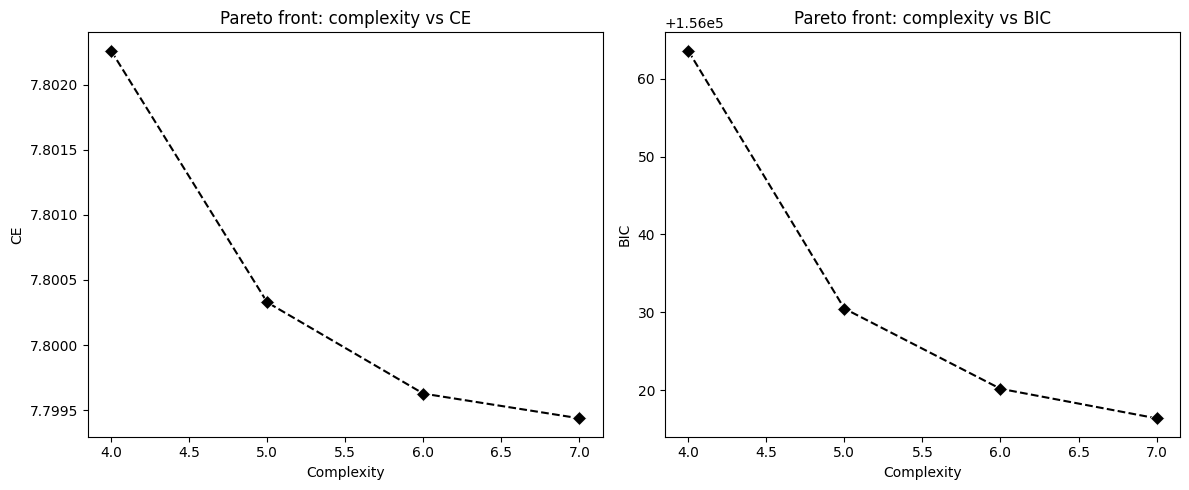


Pareto-optimal functions by CE (4):
k    CE           Comp   Equation
--------------------------------------------------------------------------------
2    7.802259     4      pow((x + 1),a0)
3    7.800328     5      pow(Abs(a0),(pow(x,a1)))
3    7.799627     6      pow(Abs(a0 - exp(x)),a1)
3    7.799437     7      exp(pow((x + 1),a0)/a1)


In [15]:
# --- Pareto front ---
arr = extract_ranked_arrays(ranked)
comps, ces, bics = arr["comps"], arr["ces"], arr["bics"]

pareto_ce = pareto_front(comps, ces)
pareto_bic = pareto_front(comps, bics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mask, vals, label in [
    (axes[0], pareto_ce, ces, "CE"),
    (axes[1], pareto_bic, bics, "BIC"),
]:
    idx = np.where(mask)[0]
    idx_sorted = idx[np.argsort(comps[idx])]
    ax.plot(comps[idx_sorted], vals[idx_sorted], 'k--', lw=1.5, zorder=5)
    ax.scatter(comps[idx_sorted], vals[idx_sorted], c='k', s=50,
               zorder=6, marker='D', edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Complexity')
    ax.set_ylabel(label)
    ax.set_title(f'Pareto front: complexity vs {label}')

plt.tight_layout()
plt.show()

# Print Pareto-optimal functions (CE front)
eqs = data["equations"]
idx_ce = np.where(pareto_ce)[0]
idx_ce = idx_ce[np.argsort(comps[idx_ce])]
print(f"\nPareto-optimal functions by CE ({pareto_ce.sum()}):")
print(f"{'k':<4} {'CE':<12} {'Comp':<6} Equation")
print("-" * 80)
for i in idx_ce:
    comp, fidx, ce, bic_, k, _ = ranked[i]
    eq = eqs[comp][fidx]
    if len(eq) > 50:
        eq = eq[:47] + "..."
    print(f"{k:<4} {ce:<12.6f} {comp:<6} {eq}")

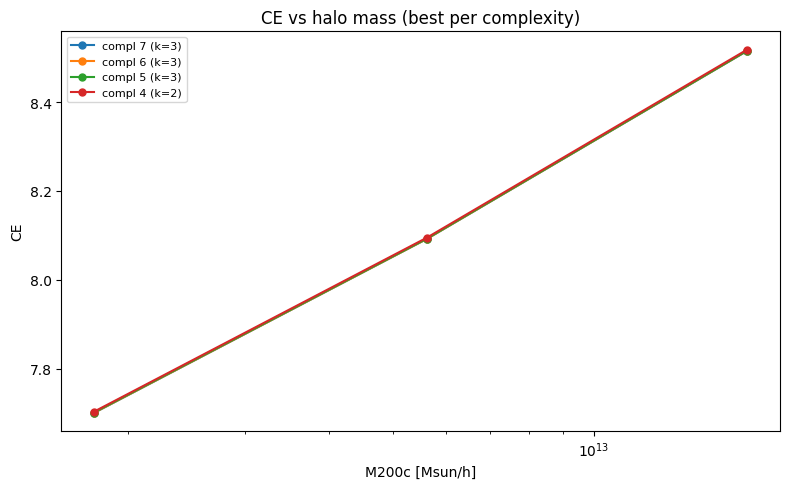

  compl 7: k=3 CE=7.799437  exp(pow((x + 1),a0)/a1)
  compl 6: k=3 CE=7.799627  pow(Abs(a0 - exp(x)),a1)
  compl 5: k=3 CE=7.800328  pow(Abs(a0),(pow(x,a1)))
  compl 4: k=2 CE=7.802259  pow((x + 1),a0)

MASS BIN [1.00e+12, 3.16e+12) — 720 halos
Rank   Comp   Func#   CE           Delta_CE     dBIC       k    #Halo   Equation
----------------------------------------------------------------------------------------------------
1      7      72485   7.699933     0.000000     0.0        3    720     exp(pow((x + 1),a0)/a1)
2      7      22769   7.699960     0.000027     0.5        3    720     pow(Abs(a0),(pow(x,(a1 + x))))
3      7      8051    7.700089     0.000156     3.1        3    720     pow(Abs(a0 - x),(a1 - x))
4      7      70679   7.700103     0.000170     3.4        3    720     pow((x + pow(Abs(a0),x)),a1)
5      7      44450   7.700131     0.000198     4.0        3    720     pow(Abs(a0 - exp(exp(x))),a1)
6      7      47677   7.700140     0.000207     4.1        3    720     p

In [16]:
# --- CE vs halo mass (best per complexity) + per-bin rankings ---
mass_edges = np.array([1e12, 10**12.5, 1e13, np.inf])
n_mass_bins = len(mass_edges) - 1
n_show_bin = 10

eqs = data["equations"]
M200c = data["M200c"]
halo_idx_arr = data["halo_idx"]

# Pick the best function per complexity level
best_per_comp = {}
for comp_r, fidx_r, ce, bic_, k, n_h in ranked:
    if comp_r not in best_per_comp:
        best_per_comp[comp_r] = (comp_r, fidx_r, ce, bic_, k, n_h)

# --- Plot: CE vs mass for best function per complexity ---
fig, ax = plt.subplots(figsize=(8, 5))

for comp_r, fidx_r, _, _, k, _ in best_per_comp.values():
    fmask = ((data["comp"] == comp_r) & (data["func_idx"] == fidx_r)
             & halo_mask[halo_idx_arr])
    f_halo = halo_idx_arr[fmask]
    f_ce = data["ce"][fmask]

    bin_ces, bin_centers = [], []
    for bi in range(n_mass_bins):
        in_bin = ((M200c[f_halo] >= mass_edges[bi])
                  & (M200c[f_halo] < mass_edges[bi + 1]))
        if in_bin.sum() > 0:
            bin_ces.append(np.mean(f_ce[in_bin]))
            if np.isinf(mass_edges[bi + 1]):
                bin_centers.append(
                    10**np.mean(np.log10(M200c[f_halo][in_bin])))
            else:
                bin_centers.append(
                    np.sqrt(mass_edges[bi] * mass_edges[bi + 1]))

    eq = eqs[comp_r][fidx_r]
    ax.plot(bin_centers, bin_ces, 'o-',
            label=f"compl {comp_r} (k={k})", ms=5)

ax.set_xscale('log')
ax.set_xlabel(f"M200c [{data['units_M200c']}]")
ax.set_ylabel('CE')
ax.set_title('CE vs halo mass (best per complexity)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Print which function is plotted for each complexity
for comp_r, fidx_r, ce, _, k, _ in best_per_comp.values():
    print(f"  compl {comp_r}: k={k} CE={ce:.6f}  {eqs[comp_r][fidx_r]}")

# --- Print: top functions per mass bin ---
for bi in range(n_mass_bins):
    lo, hi = mass_edges[bi], mass_edges[bi + 1]
    bin_halo_mask = halo_mask & (M200c >= lo) & (M200c < hi)

    _, bin_ranked = compute_scores(
        data, halo_mask=bin_halo_mask,
        min_success_fraction=0.5,
        failure_loss_percentile=95)

    if max_params is not None:
        bin_ranked = [r for r in bin_ranked if r[4] <= max_params]

    n_halos_bin = int(bin_halo_mask.sum())
    hi_str = f"{hi:.2e}" if np.isfinite(hi) else "inf"
    print_ranking_table(
        bin_ranked, eqs,
        f"MASS BIN [{lo:.2e}, {hi_str}) — {n_halos_bin} halos",
        n_top=n_show_bin)
    print()